In [1]:
# Step 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Step 2: Dataset Load karo
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("✅ Datasets loaded successfully!")
print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)
print("\nMatches Columns:", matches.columns.tolist())
matches.head()

✅ Datasets loaded successfully!
Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)

Matches Columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
# Step 3: Data Exploration
print("Missing Values:")
print(matches.isnull().sum())
print("\nTop Teams:")
print(matches['team1'].value_counts().head(10))

Missing Values:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Top Teams:
team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Name: count, dtype: int64


In [4]:
# Step 4: KKR Analysis - Win Rate
print("=== Kolkata Knight Riders Analysis ===")
kkr_matches = matches[(matches['team1'] == 'Kolkata Knight Riders') | 
                       (matches['team2'] == 'Kolkata Knight Riders')]
kkr_wins = matches[matches['winner'] == 'Kolkata Knight Riders']

print(f"Total Matches Played: {len(kkr_matches)}")
print(f"Total Wins: {len(kkr_wins)}")
print(f"Win Rate: {len(kkr_wins)/len(kkr_matches)*100:.2f}%")

# Season wise wins
kkr_season_wins = kkr_wins.groupby('season').size()
print("\nKKR Wins per Season:")
print(kkr_season_wins)

=== Kolkata Knight Riders Analysis ===
Total Matches Played: 251
Total Wins: 131
Win Rate: 52.19%

KKR Wins per Season:
season
2007/08     6
2009        3
2009/10     7
2011        8
2012       12
2013        6
2014       11
2015        7
2016        8
2017        9
2018        9
2019        6
2020/21     7
2021        9
2022        6
2023        6
2024       11
dtype: int64


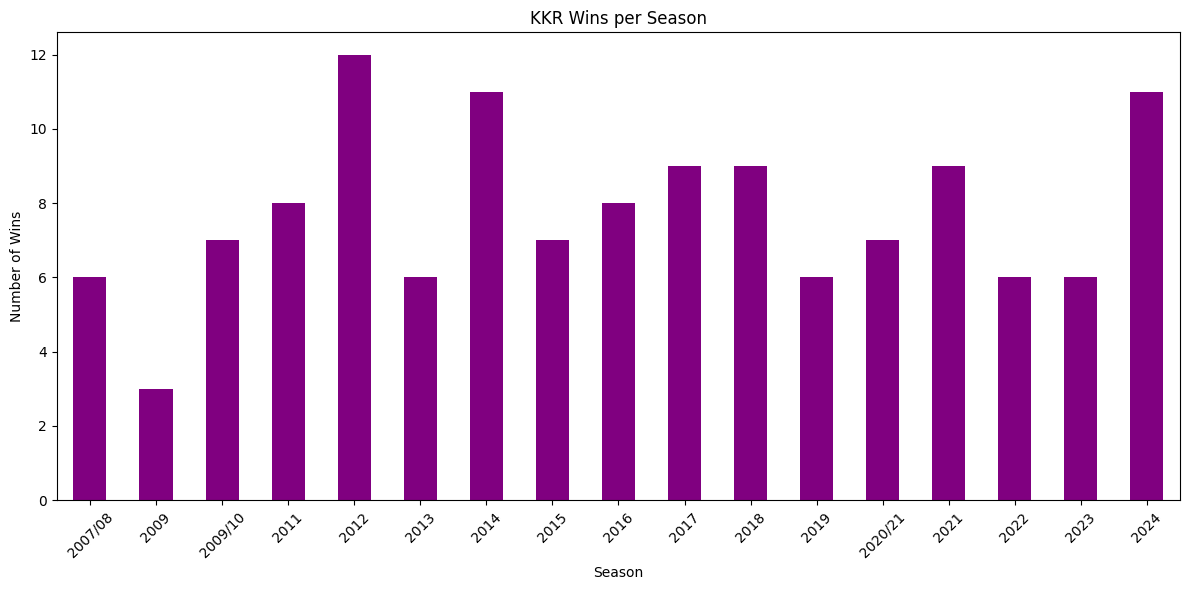

✅ KKR Season Wins plot saved!


In [5]:
# Step 5: KKR Season Wins Visualization
plt.figure(figsize=(12, 6))
kkr_season_wins.plot(kind='bar', color='purple')
plt.title('KKR Wins per Season')
plt.xlabel('Season')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('kkr_season_wins.png')
plt.show()
print("✅ KKR Season Wins plot saved!")

In [6]:
# Step 6: Match Prediction Model banao
# Features prepare karo
df_model = matches[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']].dropna()

le = LabelEncoder()
df_model['team1'] = le.fit_transform(df_model['team1'])
df_model['team2'] = le.fit_transform(df_model['team2'])
df_model['toss_winner'] = le.fit_transform(df_model['toss_winner'])
df_model['toss_decision'] = le.fit_transform(df_model['toss_decision'])
df_model['venue'] = le.fit_transform(df_model['venue'])
df_model['winner'] = le.fit_transform(df_model['winner'])

X = df_model[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']]
y = df_model['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data prepared!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

✅ Data prepared!
Training size: (872, 5)
Testing size: (218, 5)


In [7]:
# Step 7: Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("✅ Model trained successfully!")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

✅ Model trained successfully!
Accuracy: 0.4771


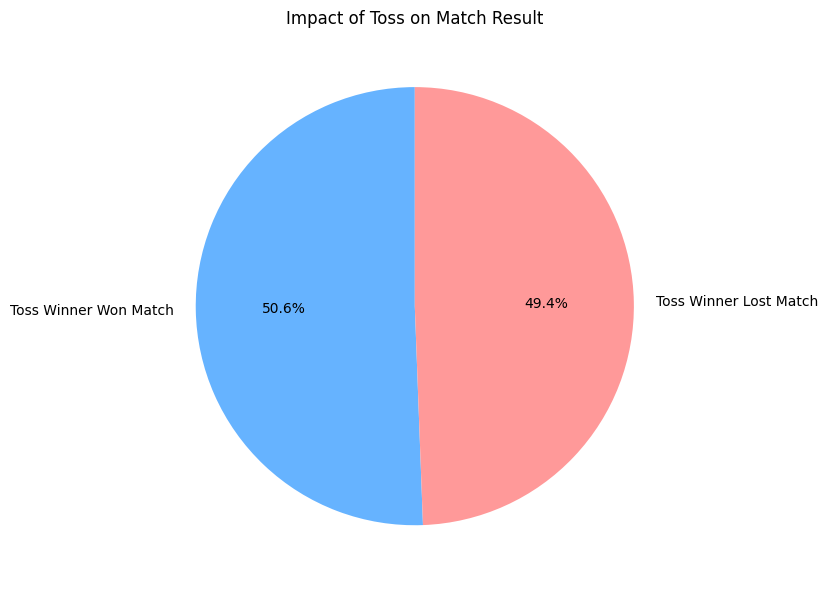

✅ Toss Analysis plot saved!


In [8]:
# Step 8: Toss Analysis Visualization
plt.figure(figsize=(10, 6))
toss_win = matches[matches['toss_winner'] == matches['winner']]
toss_lose = matches[matches['toss_winner'] != matches['winner']]

labels = ['Toss Winner Won Match', 'Toss Winner Lost Match']
sizes = [len(toss_win), len(toss_lose)]
colors = ['#66b3ff', '#ff9999']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Impact of Toss on Match Result')
plt.tight_layout()
plt.savefig('toss_analysis.png')
plt.show()
print("✅ Toss Analysis plot saved!")

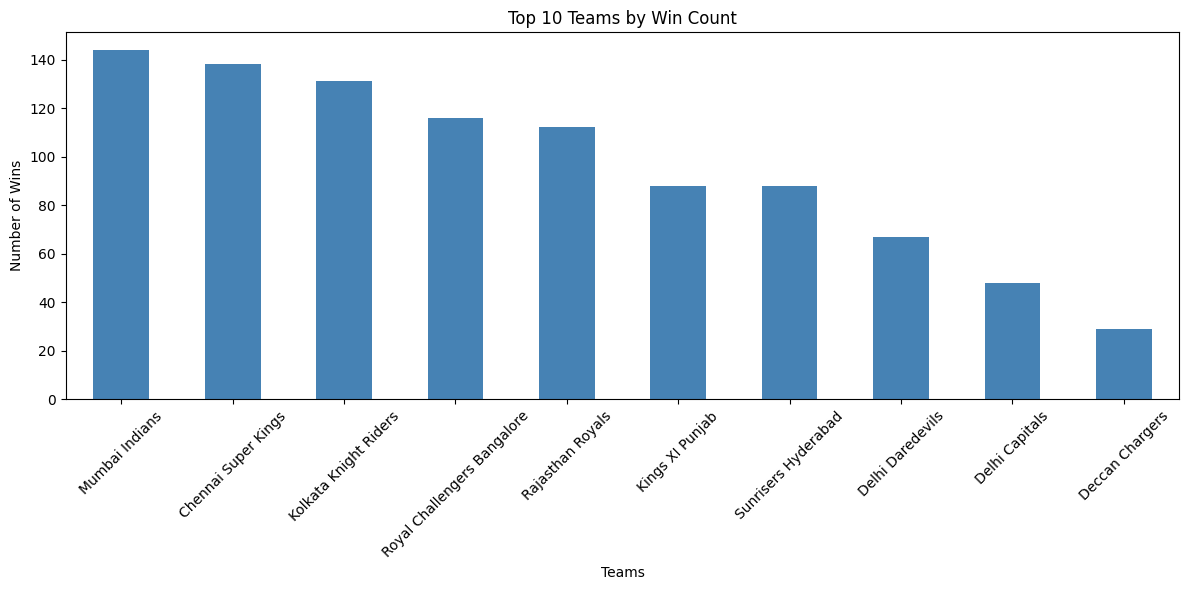

✅ Top Teams plot saved!


In [9]:
# Step 9: Top Teams Win Count Visualization
plt.figure(figsize=(12, 6))
top_teams = matches['winner'].value_counts().head(10)
top_teams.plot(kind='bar', color='steelblue')
plt.title('Top 10 Teams by Win Count')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_teams_wins.png')
plt.show()
print("✅ Top Teams plot saved!")

In [10]:
# Step 10: Model Save karo
import joblib
joblib.dump(rf_model, 'ipl_model.pkl')
print("✅ IPL Model saved as ipl_model.pkl!")

✅ IPL Model saved as ipl_model.pkl!
